# Datenvorverarbeitung für NIDS auf Basis des NF-UNSW-NB15-v3 Datensatzes

**Autor:** Nikolai Steffan 
**Datum:** 25.11.2025  
**Ziel:** Dieses Notebook dient der systematischen Aufbereitung des NF-UNSW-NB15-v3-Datensatzes für das Training eines Machine-Learning-basierten Intrusion-Detection-Systems (NIDS).

---

## 1. Einleitung und Zielsetzung

In dieser Phase des Projekts wird der Rohdatensatz `NF-UNSW-NB15-v3` transformiert, um ihn für das maschinelle Lernen nutzbar zu machen. Die Hauptziele dieses Notebooks sind:
1.  **Datenbereinigung:** Entfernen von irrelevanten oder redundanten Merkmalen.
2.  **Merkmals-Engineering:** Umwandlung von kategorialen Daten in ein numerisches Format.
3.  **Normalisierung/Standardisierung:** Skalierung der numerischen Merkmale, um eine konsistente Verteilung zu gewährleisten.
4.  **Behandlung von Klassenungleichgewicht:** Sicherstellung einer ausbalancierten Verteilung der Angriffsklassen für ein faires Modelltraining.
5.  **Aufteilung der Daten:** Erstellung von Trainings- und Test-Sets zur späteren Modellevaluierung.

---

## 2. Setup: Importieren der Bibliotheken

Zuerst werden alle notwendigen Python-Bibliotheken importiert. Dies umfasst Bibliotheken für die Datenmanipulation (`pandas`, `numpy`), das maschinelle Lernen (`scikit-learn`), die Behandlung von unausgeglichenen Datensätzen (`imbalanced-learn`) sowie für die Visualisierung (`matplotlib`, `seaborn`). Ein fester `random_state` wird definiert, um die Reproduzierbarkeit aller stochastischen Prozesse sicherzustellen.

In [1]:
%pip install transformers torch pandas scikit-learn matplotlib seaborn requests

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 📚 Import Libraries und Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing Libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# Sampling Libraries
try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler
    print("✅ Imbalanced-learn libraries erfolgreich geladen")
except ImportError:
    print("⚠️ Installing imbalanced-learn...")
    !pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler

import joblib
import os

# Visualization Setup
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', 20)

print("🚀 Setup completed!")
print(f"📊 Pandas: {pd.__version__} | NumPy: {np.__version__}")

✅ Imbalanced-learn libraries erfolgreich geladen
🚀 Setup completed!
📊 Pandas: 2.2.2 | NumPy: 1.26.4


---

## 3. Datenbasis: Laden und erste Analyse

### 3.1. Laden des Datensatzes

Die Daten werden aus der CSV-Datei `NF-UNSW-NB15-v3.csv` geladen. Anschließend werden die Dimensionen des Datensatzes (Anzahl der Zeilen und Spalten) sowie der Speicherbedarf ausgegeben, um einen ersten Überblick zu erhalten.

In [3]:
# 📁 Dataset Loading
# WICHTIG: Pfad zum NF-UNSW-NB15-v3.csv anpassen!
data_path = "../data/NF-UNSW-NB15-v3.csv" 

try:
    print("📥 Lade NF-UNSW-NB15-v3 Dataset...")
    df = pd.read_csv(data_path)
    print(f"✅ Dataset erfolgreich geladen!")
    print(f"📊 Shape: {df.shape}")
    print(f"💾 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print("❌ Dataset nicht gefunden!")
    

📥 Lade NF-UNSW-NB15-v3 Dataset...
✅ Dataset erfolgreich geladen!
📊 Shape: (2365424, 55)
💾 Memory: 1390.30 MB


---

## 4. Datenvorverarbeitung (Preprocessing)

In diesem zentralen Abschnitt werden die Daten schrittweise bereinigt und transformiert.



### 4.1 Entfernung von Spalten, die Duplikate oder Konstanten sind


In [4]:
# 🗑️ Step 1: Drop Useless Columns
print("=" * 50)
print("🗑️ DROPPING USELESS COLUMNS")
print("=" * 50)
print("\n📋 Initial Columns:")
print(df.columns.tolist())
original_shape = df.shape
# Excluded columns: Time features were excluded based on dataset being collected on only two days. Other features excluded based on correlation analysis and domain knowledge.
columns_to_drop = []
# 1. ID columns
#id_cols = [col for col in df.columns if 'id' in col.lower() or 'index' in col.lower()]
#print(f"ID columns: {id_cols}")
#columns_to_drop.extend(id_cols)

# 2. High missing values (>50%)
missing_pct = (df.isnull().sum() / len(df)) * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
print(f"Columns with >50% missing values: {high_missing}")
columns_to_drop.extend(high_missing)

# 3. Constant columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
constant_cols = [col for col in numeric_cols if col not in ['Label'] and df[col].nunique() == 1]
print(f"Constant columns: {constant_cols}")
columns_to_drop.extend(constant_cols)

# Remove duplicates
columns_to_drop = list(set(columns_to_drop))
print(columns_to_drop)

if columns_to_drop:
    print(f"🗑️ Dropping {len(columns_to_drop)} columns: {columns_to_drop}")
    df_cleaned = df.drop(columns=columns_to_drop)
else:
    print("✅ No columns to drop")
    df_cleaned = df.copy()


# Berechne den Prozentsatz fehlender Werte pro Zeile
missing_pct_rows = (df.isnull().sum(axis=1) / df.shape[1]) * 100
rows_to_drop = missing_pct_rows[missing_pct_rows > 50].index.tolist()
if columns_to_drop:
    print(f"🗑️ Dropping {len(rows_to_drop)} rows: {rows_to_drop}")
    df = df.drop(index=rows_to_drop)
else:
    print("✅ No rows to drop")

print(f"\n📊 Shape: {original_shape} → {df_cleaned.shape}")
print(f"📈 Reduction: {(1 - df_cleaned.shape[1]/df.shape[1])*100:.1f}%")
display(df_cleaned.head())


🗑️ DROPPING USELESS COLUMNS

📋 Initial Columns:
['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'SRC_TO_DST_IAT_MIN', 'SRC_TO_DST_IAT_MAX',

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [5]:
import numpy as np
import pandas as pd

def clean_flow_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bereinigt einen DataFrame von Netzwerk-Flow-Daten, um Probleme mit
    unendlichen Werten und NaN-Werten zu beheben, die durch eine Flow-Dauer
    von Null entstehen.

    Diese Funktion identifiziert Zeilen, in denen 'FLOW_DURATION_MILLISECONDS'
    Null ist, und setzt diesen Wert auf 1, um eine Division durch Null zu
    vermeiden. Anschließend werden 'SRC_TO_DST_SECOND_BYTES' und
    'DST_TO_SRC_SECOND_BYTES' für die betroffenen Zeilen basierend auf der
    neuen Dauer neu berechnet.

    Zusätzlich werden alle verbleibenden NaN-Werte in den ratenbasierten
    Spalten mit 0 gefüllt.

    Returns:
        Der bereinigte DataFrame.
    """
    # Erstellen einer Kopie, um die ursprünglichen Daten nicht zu verändern
    df_cleaned = df.copy()

    # Maske für Zeilen, bei denen die Dauer 0 ist
    zero_duration_mask = df_cleaned['FLOW_DURATION_MILLISECONDS'] == 0

    # Setzen der Dauer auf 1 ms für diese Zeilen
    df_cleaned.loc[zero_duration_mask, 'FLOW_DURATION_MILLISECONDS'] = 1

    # Neuberechnung der Raten für die geänderten Zeilen
    new_duration_seconds = df_cleaned.loc[zero_duration_mask, 'FLOW_DURATION_MILLISECONDS']

    # Neuberechnung für SRC_TO_DST_SECOND_BYTES
    df_cleaned.loc[zero_duration_mask, 'SRC_TO_DST_SECOND_BYTES'] = \
        df_cleaned.loc[zero_duration_mask, 'OUT_BYTES'] / new_duration_seconds

    # Neuberechnung für DST_TO_SRC_SECOND_BYTES
    df_cleaned.loc[zero_duration_mask, 'DST_TO_SRC_SECOND_BYTES'] = \
        df_cleaned.loc[zero_duration_mask, 'IN_BYTES'] / new_duration_seconds


    print(f"{zero_duration_mask.sum()} Zeilen mit einer Dauer von 0 wurden auf 1 ms korrigiert und die Raten neu berechnet.")

    return df_cleaned

df_cleaned = clean_flow_data(df_cleaned)



122493 Zeilen mit einer Dauer von 0 wurden auf 1 ms korrigiert und die Raten neu berechnet.


### 4.1. Merkmals-Engineering und -Kodierung

Machine-Learning-Modelle erfordern numerische Eingaben. Daher müssen alle kategorialen Merkmale in ein numerisches Format umgewandelt werden.

**Kategorische Merkmale:** Spalten wie IP-Adressen, Ports und Protokolle werden mittels `LabelEncoder` in Ganzzahlen umgewandelt. Diese Methode ist speichereffizient und für viele Modelle ausreichend.

**Zielvariable:** Die `Attack`-Spalte wird ebenfalls numerisch kodiert. Die Zuordnung von Kategoriename zu ID wird in der Datei `attack_category_mapping.npy` gespeichert, um später die Modellausgaben interpretieren zu können.


In [6]:
from sklearn.impute import SimpleImputer


df_processed = df_cleaned.copy()

# Identify feature types
target_columns = ['Label', 'Attack']
categorical_columns = ['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO','FTP_COMMAND_RET_CODE', 'DNS_QUERY_TYPE', 'ICMP_IPV4_TYPE', 'ICMP_TYPE', 'SERVER_TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'TCP_FLAGS' ]

feature_columns = [col for col in df_processed.columns if col not in target_columns]
numeric_columns = list(np.setdiff1d(feature_columns, categorical_columns))

for col in categorical_columns:
    if col not in df_processed.columns:
        print(f"⚠️ Warning: Categorical column {col} not found in DataFrame.")
        categorical_columns.remove(col)
print(f"📊 Numeric features: {len(numeric_columns)}")
print(f"🏷️ Categorical features: {len(categorical_columns)}")
print('____________________')
print(df_processed.shape)

# Encode categorical features
for col in categorical_columns:
    if col in df_processed.columns:
        unique_vals = df_processed[col].nunique()
        print(f"\n🔄 Processing {col}: {unique_vals} unique values")

        # Label encoding for many categories
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        print(f"  ✅ Label encoded: {unique_vals} → 0-{unique_vals-1}")
print('____________________')
print(df_processed.shape)
# Ersetze unendliche Werte durch NaN in den numerischen Spalten
df_processed[numeric_columns] = df_processed[numeric_columns].replace([np.inf, -np.inf], np.nan)
# Handle missing values
# Instanziere den Imputer
imputer = SimpleImputer(strategy='median')

# Fit und Transform; Ergebnis als NumPy-Array
numeric_imputed_array = imputer.fit_transform(df_processed[numeric_columns])

# Rückführung in DataFrame mit den ursprünglichen Spaltennamen
df_numeric_imputed = pd.DataFrame(numeric_imputed_array,
                                  columns=numeric_columns,
                                  index=df_processed.index)

# Setze die imputierten numerischen Daten zurück in df_processed
df_processed[numeric_columns] = df_numeric_imputed


#df_processed = impute_missing_numeric(df_processed, target_columns=numeric_columns, method='median')

# Encode target variable
if 'Attack' in df_processed.columns:
    print("\n🎯 Encoding Attack Categories")
    le_target = LabelEncoder()
    df_processed['Attack_Category_Encoded'] = le_target.fit_transform(df_processed['Attack'])
    
    # Save mapping
    category_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
    print("\nCategory Mapping:")
    for category, encoded in category_mapping.items():
        print(f"  {encoded}: {category}")
    
    np.save('attack_category_mapping.npy', category_mapping)
    print("\n💾 Mapping saved to 'attack_category_mapping.npy'")

# Final feature list
final_feature_columns = [col for col in df_processed.columns 
                        if col not in target_columns + ['Attack_Category_Encoded']]

print(f"\n📊 Final shape: {df_processed.shape}")
print(f"✅ Final features: {len(final_feature_columns)}")

print(df_processed.shape)
display(df_processed.head())

📊 Numeric features: 40
🏷️ Categorical features: 13
____________________
(2365424, 55)

🔄 Processing IPV4_SRC_ADDR: 40 unique values
  ✅ Label encoded: 40 → 0-39

🔄 Processing L4_SRC_PORT: 64597 unique values
  ✅ Label encoded: 64597 → 0-64596

🔄 Processing IPV4_DST_ADDR: 40 unique values
  ✅ Label encoded: 40 → 0-39

🔄 Processing L4_DST_PORT: 64617 unique values
  ✅ Label encoded: 64617 → 0-64616

🔄 Processing PROTOCOL: 255 unique values
  ✅ Label encoded: 255 → 0-254

🔄 Processing L7_PROTO: 141 unique values
  ✅ Label encoded: 141 → 0-140

🔄 Processing FTP_COMMAND_RET_CODE: 16 unique values
  ✅ Label encoded: 16 → 0-15

🔄 Processing DNS_QUERY_TYPE: 20 unique values
  ✅ Label encoded: 20 → 0-19

🔄 Processing ICMP_IPV4_TYPE: 256 unique values
  ✅ Label encoded: 256 → 0-255

🔄 Processing ICMP_TYPE: 1188 unique values
  ✅ Label encoded: 1188 → 0-1187

🔄 Processing SERVER_TCP_FLAGS: 14 unique values
  ✅ Label encoded: 14 → 0-13

🔄 Processing CLIENT_TCP_FLAGS: 14 unique values
  ✅ Label enc

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,Attack_Category_Encoded
0,1.424242e+12,1.424242e+12,32,42852,16,47336,79,103,146.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Benign,2
1,1.424242e+12,1.424242e+12,34,46962,19,24202,211,6,4704.0,28.0,...,91.0,12.0,19.0,0.0,90.0,12.0,19.0,0,Benign,2
2,1.424242e+12,1.424242e+12,30,41037,22,61467,211,79,13662.0,238.0,...,1843.0,10.0,119.0,0.0,1843.0,5.0,88.0,0,Benign,2
3,1.424242e+12,1.424242e+12,38,36654,20,47336,79,103,146.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Benign,2
4,1.424242e+12,1.424242e+12,31,39472,4,47336,79,103,130.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Benign,2


### 4.3. Transformation numerischer Merkmale

Numerische Merkmale in Netzwerkdaten weisen oft stark verzerrte Verteilungen (engl. "skewed distributions") auf. Um den Einfluss von Extremwerten zu reduzieren und die Verteilungen symmetrischer zu gestalten, wird eine **logarithmische Transformation** (`log(x+1)`) angewendet. Anschließend werden die Werte mittels **Min-Max-Skalierung** in den Bereich `[0, 1]` normalisiert. Dieser zweistufige Prozess hat sich in der Praxis für NIDS-Daten bewährt.

In [7]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import joblib

# ==============================================================================
# Benutzerdefinierter Transformer, der die ursprüngliche Logik exakt nachbildet
# ==============================================================================
class CustomLogScaler(BaseEstimator, TransformerMixin):
    """
    Ein benutzerdefinierter Scaler, der die ursprüngliche manuelle Transformation exakt nachbildet:
    f(v) = log(v - min + 1) / log(max - min + 1)
    """
    def __init__(self):
        self.min_ = 0
        self.range_ = 0

    def fit(self, X, y=None):
        # Berechnet min und range aus den Trainingsdaten
        self.min_ = X.min()
        self.range_ = X.max() - self.min_
        return self

    def transform(self, X, y=None):
        # Wendet die exakte Transformation an
        X_transformed = X - self.min_
        
        # Logarithmus anwenden
        X_transformed = np.log1p(X_transformed) # log1p(x) ist log(x+1)
        
        # Skalieren, sodass der Maximalwert 1 ist
        log_range_plus_1 = np.log1p(self.range_)
        if log_range_plus_1 > 0:
            X_transformed = X_transformed / log_range_plus_1
        else:
            # Wenn alle Werte gleich sind, ist das Ergebnis 0
            X_transformed[:] = 0
            
        # Clipping, um sicherzustellen, dass die Werte im Bereich [0, 1] liegen
        return np.clip(X_transformed, 0., 1.)

# ==============================================================================
# Angepasste Preprocessing-Funktion
# ==============================================================================
def preprocess_numerical_columns(dataset, numerical_columns, clip_numerical_values=True):
    """
    Wendet die benutzerdefinierte logarithmische Skalierung auf numerische Spalten an
    und speichert die trainierten Scaler.
    """
    df_processed = dataset.copy()
    
    # Bereinigung der numerischen Spalten
    print("Converting numerical columns to floats, and removing out of range values...")
    for col_name in numerical_columns:
        col_values = df_processed[col_name].values
        col_values[~np.isfinite(col_values)] = 0
        df_processed[col_name] = col_values.astype("float32")

    # Erstellen einer Pipeline für jede Spalte mit dem benutzerdefinierten Scaler
    scalers = {}
    print(f"Applying pre-processing to numerical values")
    for i, col_name in enumerate(numerical_columns):
        print(f"[Numerical {i+1:,} / {len(numerical_columns)}] Processing numerical column {col_name}...")
        
        # Die Pipeline enthält jetzt nur noch unseren CustomLogScaler
        pipeline = Pipeline([
            ('custom_log_scaler', CustomLogScaler())
        ])
        
        # Pipeline anpassen und Daten transformieren
        col_data = df_processed[[col_name]].values
        df_processed[col_name] = pipeline.fit_transform(col_data)
        
        # Pipeline für den Export speichern
        scalers[col_name] = pipeline

    # Speichern des Dictionaries mit allen Scalern
    scaler_filename = '../data/scalers.joblib'
    joblib.dump(scalers, scaler_filename)
    print(f"\n✅ Scaler-Objekte in '{scaler_filename}' gespeichert.")

    # Die nicht-numerischen Spalten wieder hinzufügen
    for col in dataset.columns:
        if col not in numerical_columns:
            df_processed[col] = dataset[col]

    return df_processed


In [8]:
df_processed=preprocess_numerical_columns(dataset=df_processed,numerical_columns=numeric_columns)

# The scope of these changes made to
# pandas settings are local to with statement.
with pd.option_context('display.max_rows', 10,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    display(df_processed)


Converting numerical columns to floats, and removing out of range values...
Applying pre-processing to numerical values
[Numerical 1 / 40] Processing numerical column DNS_QUERY_ID...
[Numerical 2 / 40] Processing numerical column DNS_TTL_ANSWER...
[Numerical 3 / 40] Processing numerical column DST_TO_SRC_AVG_THROUGHPUT...
[Numerical 4 / 40] Processing numerical column DST_TO_SRC_IAT_AVG...
[Numerical 5 / 40] Processing numerical column DST_TO_SRC_IAT_MAX...
[Numerical 6 / 40] Processing numerical column DST_TO_SRC_IAT_MIN...
[Numerical 7 / 40] Processing numerical column DST_TO_SRC_IAT_STDDEV...
[Numerical 8 / 40] Processing numerical column DST_TO_SRC_SECOND_BYTES...
[Numerical 9 / 40] Processing numerical column DURATION_IN...
[Numerical 10 / 40] Processing numerical column DURATION_OUT...
[Numerical 11 / 40] Processing numerical column FLOW_DURATION_MILLISECONDS...
[Numerical 12 / 40] Processing numerical column FLOW_END_MILLISECONDS...
[Numerical 13 / 40] Processing numerical colum

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,Attack_Category_Encoded
0,1.000,1.000,32,42852,16,47336,79,103,0.291,0.070,0.314,0.118,0,0,0,0.059,0.000,0.000,0.625,0.625,0.565,0.524,0.660,0.565,0.536,0.474,0.000,0.000,0.000,0.000,0.740,0.770,0.195,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0.970,1,0.185,0,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0,Benign,2
1,1.000,1.000,34,46962,19,24202,211,6,0.494,0.336,0.485,0.362,11,11,11,0.497,0.497,0.497,0.625,0.631,0.940,0.441,0.609,0.940,0.273,0.299,0.463,0.226,0.441,0.226,0.668,0.658,0.431,0.517,0.140,0.170,0.000,0.864,0.864,818,108,0.000,0,0.000,0,0.0,0.411,0.249,0.290,0.0,0.410,0.259,0.292,0,Benign,2
2,1.000,1.000,30,41037,22,61467,211,79,0.556,0.552,0.801,0.654,11,11,11,0.667,0.667,0.667,0.625,0.631,0.999,0.441,0.609,0.999,0.645,0.207,0.454,0.335,0.792,0.613,0.615,0.848,0.687,0.000,0.205,0.541,0.600,0.999,0.943,828,111,0.000,0,0.000,0,0.0,0.683,0.232,0.464,0.0,0.683,0.181,0.437,0,Benign,2
3,1.000,1.000,38,36654,20,47336,79,103,0.291,0.070,0.314,0.118,0,0,0,0.000,0.000,0.000,0.625,0.625,0.565,0.524,0.660,0.565,0.618,0.550,0.000,0.000,0.000,0.000,0.763,0.794,0.195,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0.728,1,0.185,0,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0,Benign,2
4,1.000,1.000,31,39472,4,47336,79,103,0.284,0.070,0.309,0.118,0,0,0,0.000,0.000,0.000,0.625,0.625,0.546,0.498,0.642,0.546,0.607,0.537,0.000,0.000,0.000,0.000,0.756,0.788,0.195,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0.781,1,0.185,0,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0,Benign,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2365419,0.817,0.817,36,63235,21,16507,211,79,0.605,0.377,0.476,0.369,10,10,10,0.490,0.490,0.490,0.625,0.631,0.999,0.441,0.609,0.999,0.266,0.511,0.587,0.301,0.420,0.208,0.782,0.654,0.472,0.193,0.140,0.000,0.312,0.854,0.917,385,13,0.000,0,0.000,0,0.0,0.391,0.202,0.300,0.0,0.392,0.242,0.318,0,Benign,2
2365420,0.817,0.817,32,40507,4,46123,211,79,0.446,0.312,0.474,0.346,11,11,11,0.153,0.153,0.153,0.625,0.631,0.823,0.441,0.609,0.823,0.718,0.644,0.405,0.211,0.428,0.208,0.843,0.875,0.444,0.282,0.205,0.000,0.000,0.854,0.854,1125,174,0.000,0,0.000,0,0.0,0.063,0.000,0.000,0.0,0.063,0.000,0.000,0,Benign,2
2365421,0.817,0.817,32,41334,15,56417,211,79,0.532,0.266,0.350,0.209,11,11,4,0.462,0.462,0.462,0.625,0.631,0.999,0.441,0.609,0.999,0.106,0.410,0.510,0.175,0.000,0.000,0.729,0.551,0.328,0.000,0.000,0.000,0.199,0.781,0.832,899,127,0.000,0,0.000,0,0.0,0.468,0.275,0.373,0.0,0.469,0.384,0.411,0,Benign,2
2365422,0.817,0.817,33,38505,18,47336,79,103,0.291,0.070,0.314,0.118,0,0,0,0.000,0.000,0.000,0.625,0.625,0.565,0.524,0.660,0.565,0.618,0.550,0.000,0.000,0.000,0.000,0.763,0.794,0.195,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0.709,1,0.185,0,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0,Benign,2


# Anpassung des Datensatzes nach den zuvor gewonnenen Erkenntnissen:

As part of the data pre-processing, the flow identifiers such as IDs, source/destination IP
and ports, timestamps, and start/end time are dropped to avoid learning bias towards attacking and victim
end nodes. For the UNSW-NB15 and NF-UNSW-NB15-v2 datasets, The Time To Live (TTL)-based fea-
tures are dropped due to their extreme correlation with the labels. https://arxiv.org/pdf/2101.11315

In [9]:
def feature_selection(df):
    # 🗑️ Step 1: Drop Useless Columns
    print("=" * 50)
    print("🗑️ DROPPING USELESS COLUMNS")
    print("=" * 50)
    print("\n📋 Initial Columns:")
    original_shape = df.shape
    # Excluded columns: Time features were excluded based on dataset being collected on only two days. Other features excluded based on correlation analysis and domain knowledge.
    columns_to_drop = [
        'FLOW_END_MILLISECONDS', # Daten wurden nur an 2 Tagen erhoben. Daher wenig Aussagekraft
        'FLOW_START_MILLISECONDS', # Daten wurden nur an 2 Tagen erhoben. Daher wenig Aussagekraft
        'MAX_IP_PKT_LEN', # Sehr hohe Korrelation mit LONGEST_FLOW_PKT. MAX_IP_PKT_LEN ist in der Regel kleiner oder gleich LONGEST_FLOW_PKT, da es nur IPs betrachtet. LONGEST_FLOW_PKT hingegen die gesamte Schicht betrachtet. Das scheint in diesen Daten aber nicht der Fall zu sein.
        'IPV4_SRC_ADDR', # Wird entfernt um Bias zu Attack und Target Nodes zu vermeiden (siehe Zitat oben)
        'IPV4_DST_ADDR', # Wird entfernt um Bias zu Attack und Target Nodes zu vermeiden (siehe Zitat oben)
        'L4_SRC_PORT', # Wird entfernt um Bias zu Attack und Target Nodes zu vermeiden (siehe Zitat oben)
        'L4_DST_PORT', # Wird entfernt um Bias zu Attack und Target Nodes zu vermeiden (siehe Zitat oben)
        'MIN_TTL', # Wird entfernt, da es zu stark mit den Labels korreliert. Der Hauptgrund für die extreme TTL-Label-Korrelation liegt in der Art, wie der UNSW-NB15 Datensatz erstellt wurde. Wie die Forschungsliteratur zeigt, wurden alle Netzwerkpakete, die zu einem Angriff gehören, mit einem festen Time-To-Live (TTL) Wert versehen. Diese Designentscheidung bei der synthetischen Angriffserzeugung führte zu einer künstlichen, aber extremen Korrelation zwischen TTL-Werten und Angriffslabels.
        'MAX_TTL', # Wird entfernt, da es zu stark mit den Labels korreliert. Der Hauptgrund für die extreme TTL-Label-Korrelation liegt in der Art, wie der UNSW-NB15 Datensatz erstellt wurde. Wie die Forschungsliteratur zeigt, wurden alle Netzwerkpakete, die zu einem Angriff gehören, mit einem festen Time-To-Live (TTL) Wert versehen. Diese Designentscheidung bei der synthetischen Angriffserzeugung führte zu einer künstlichen, aber extremen Korrelation zwischen TTL-Werten und Angriffslabels.
        ]


    # Remove duplicates
    columns_to_drop = list(set(columns_to_drop))
    print(columns_to_drop)

    if columns_to_drop:
        print(f"🗑️ Dropping {len(columns_to_drop)} columns: {columns_to_drop}")
        df_cleaned = df.drop(columns=columns_to_drop)
    else:
        print("✅ No columns to drop")
        df_cleaned = df.copy()


    print(f"\n📊 Shape: {original_shape} → {df_cleaned.shape}")
    print(f"📈 Reduction: {(1 - df_cleaned.shape[1]/df.shape[1])*100:.1f}%")
    display(df_cleaned.head())
    return df_cleaned
df_reduced=feature_selection(df_processed)


🗑️ DROPPING USELESS COLUMNS

📋 Initial Columns:
['MAX_TTL', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'MIN_TTL', 'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'L4_DST_PORT', 'IPV4_SRC_ADDR', 'MAX_IP_PKT_LEN']
🗑️ Dropping 9 columns: ['MAX_TTL', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'MIN_TTL', 'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'L4_DST_PORT', 'IPV4_SRC_ADDR', 'MAX_IP_PKT_LEN']

📊 Shape: (2365424, 56) → (2365424, 47)
📈 Reduction: 16.1%


,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,...,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,Attack_Category_Encoded
0,79,103,0.291233,0.069932,0.314379,0.118030,0,0,0,0.059228,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,Benign,2
1,211,6,0.494162,0.336187,0.484756,0.361767,11,11,11,0.496802,...,0.410622,0.248568,0.290315,0.0,0.409630,0.258735,0.291981,0,Benign,2
2,211,79,0.556469,0.552099,0.800854,0.653691,11,11,11,0.667166,...,0.682861,0.232379,0.463954,0.0,0.682861,0.180740,0.437489,0,Benign,2
3,79,103,0.291233,0.069932,0.314379,0.118030,0,0,0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,Benign,2
4,79,103,0.284450,0.069932,0.308704,0.118030,0,0,0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,Benign,2


In [10]:
import pandas as pd
import numpy as np

def reduce_features_by_correlation(df: pd.DataFrame, threshold: float = 0.9) -> pd.DataFrame:
    """
    Reduziert die Anzahl der Features in einem DataFrame, indem hochkorrelierte
    Features entfernt werden.

    Von jedem Paar von Features, deren Korrelation den Schwellenwert
    überschreitet, wird eines entfernt.

    Args:
        df (pd.DataFrame): Der Eingabe-DataFrame mit den numerischen Features.
        threshold (float): Der Korrelationsschwellenwert (zwischen 0 und 1).
                           Features mit einer Korrelation über diesem Wert werden
                           als Kandidaten für die Entfernung betrachtet.
                           Standard ist 0.9.

    Returns:
        pd.DataFrame: Ein neuer DataFrame mit den reduzierten Features.
    """
    # Sicherstellen, dass nur numerische Spalten berücksichtigt werden
    df_numeric = df.select_dtypes(include=np.number)
    
    # Absolute Korrelationsmatrix berechnen
    corr_matrix = df_numeric.corr().abs()
    
    # Obere Dreiecksmatrix erstellen, um doppelte Paare zu vermeiden
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Spalten finden, die den Schwellenwert überschreiten
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    
    # Die identifizierten Spalten aus dem ursprünglichen DataFrame entfernen
    df_reduced = df.drop(columns=to_drop)
    
    print(f"Anzahl der entfernten Features: {len(to_drop)}")
    print(f"Entfernte Features: {to_drop}")
    
    return df_reduced



df_reduced = reduce_features_by_correlation(df_reduced, threshold=0.9)

print("\nReduzierter Datensatz (erste 5 Zeilen):")
display(df_reduced.head())
print("\nForm des reduzierten Datensatzes:", df_reduced.shape)

KeyboardInterrupt: 

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

def get_feature_importance(X: pd.DataFrame, y: pd.Series) -> pd.Series:
    """
    Bestimmt die Feature Importance für ein Klassifikationsproblem mit einem RandomForestClassifier.

    Diese Funktion trainiert einen RandomForestClassifier auf den gegebenen Daten,
    extrahiert die Wichtigkeit der einzelnen Features und gibt sie in absteigender
    Reihenfolge zurück.

    Args:
        X (pd.DataFrame): DataFrame mit den Feature-Spalten.
        y (pd.Series): Series mit den Ziel-Labels für die Klassifikation.

    Returns:
        pd.Series: Eine Pandas-Serie mit den Feature-Namen als Index und ihren
                   Importance-Scores als Werte, sortiert von der höchsten zur
                   niedrigsten Wichtigkeit.
    """
    # --- Step 1: Initial Diagnostic ---
    print("--- Before conversion ---")
    # This set will show us all the unique data types present in the column names
    column_types_before = {type(c).__name__ for c in X.columns}
    print(f"Column name types found: {column_types_before}")
    if len(column_types_before) > 1:
        print("WARNING: Mixed types detected in column names before conversion.")

    # Fix für gemischte Spaltenname-Typen
    X = X.copy()
    X.columns = [str(col) for col in X.columns]  # Explizite Konvertierung

    # --- Step 3: Verification Diagnostic ---
    print("\n--- After conversion ---")
    column_types_after = {type(c).__name__ for c in X.columns}
    print(f"Column name types found: {column_types_after}")
    if len(column_types_after) > 1:
        print("ERROR: Mixed types STILL DETECTED after conversion. This is unexpected.")
    else:
        print("SUCCESS: Column names are now consistently typed.")
    
    print("-" * 25) # Separator for clarity
    # Initialisierung und Training des Modells
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)

    # Extraktion der Feature Importances
    importances = model.feature_importances_

    # Erstellung einer Serie zur besseren Darstellung (Feature-Name -> Importance-Score)
    feature_importance_series = pd.Series(importances, index=X.columns)

    # Sortierung der Features nach Wichtigkeit
    sorted_feature_importance = feature_importance_series.sort_values(ascending=False)

    return sorted_feature_importance


In [ ]:
feature_importances = get_feature_importance(df_reduced[[col for col in df_reduced.columns 
                        if col not in target_columns + ['Attack_Category_Encoded']]], df_reduced['Attack'])
# Schwellenwert definieren
CUMULATIVE_THRESHOLD = 0.96

# Calculate the cumulative sum
cumulative_importance = feature_importances.cumsum()

print("\nCumulative Sum:")
print(cumulative_importance)


# (Recommended) Calculate the cumulative percentage
cumulative_percentage = cumulative_importance / feature_importances.sum()

print("\nCumulative Percentage:")
print(cumulative_percentage)

selected_features_series = cumulative_percentage[cumulative_percentage >= CUMULATIVE_THRESHOLD]
selected_feature_names = selected_features_series.index.tolist()
print(selected_feature_names)
print("reducing ", len(selected_feature_names), "features")
df_reduced = df_reduced.drop(selected_feature_names, axis=1)

--- Before conversion ---
Column name types found: {'str_', 'str'}

--- After conversion ---
Column name types found: {'str'}
SUCCESS: Column names are now consistently typed.
-------------------------

Cumulative Sum:
MIN_IP_PKT_LEN                 0.198429
SHORTEST_FLOW_PKT              0.371625
DST_TO_SRC_AVG_THROUGHPUT      0.465031
SRC_TO_DST_SECOND_BYTES        0.538396
LONGEST_FLOW_PKT               0.601328
DST_TO_SRC_SECOND_BYTES        0.656888
L7_PROTO                       0.707641
OUT_BYTES                      0.757096
DST_TO_SRC_IAT_AVG             0.805704
IN_BYTES                       0.853567
IN_PKTS                        0.879075
RETRANSMITTED_IN_BYTES         0.903037
NUM_PKTS_128_TO_256_BYTES      0.921423
DNS_QUERY_TYPE                 0.937968
ICMP_IPV4_TYPE                 0.953803
ICMP_TYPE                      0.968594
DNS_QUERY_ID                   0.981784
FTP_COMMAND_RET_CODE           0.986703
NUM_PKTS_256_TO_512_BYTES      0.991612
NUM_PKTS_1024_TO_1514

In [ ]:
df_reduced.shape

(2365424, 18)

In [ ]:
print(feature_importances)

MIN_IP_PKT_LEN                 0.198429
SHORTEST_FLOW_PKT              0.173196
DST_TO_SRC_AVG_THROUGHPUT      0.093406
SRC_TO_DST_SECOND_BYTES        0.073365
LONGEST_FLOW_PKT               0.062933
DST_TO_SRC_SECOND_BYTES        0.055560
L7_PROTO                       0.050753
OUT_BYTES                      0.049455
DST_TO_SRC_IAT_AVG             0.048608
IN_BYTES                       0.047863
IN_PKTS                        0.025508
RETRANSMITTED_IN_BYTES         0.023962
NUM_PKTS_128_TO_256_BYTES      0.018387
DNS_QUERY_TYPE                 0.016545
ICMP_IPV4_TYPE                 0.015835
ICMP_TYPE                      0.014791
DNS_QUERY_ID                   0.013189
FTP_COMMAND_RET_CODE           0.004920
NUM_PKTS_256_TO_512_BYTES      0.004909
NUM_PKTS_1024_TO_1514_BYTES    0.004535
NUM_PKTS_512_TO_1024_BYTES     0.002756
SRC_TO_DST_IAT_MIN             0.001090
DST_TO_SRC_IAT_MIN             0.000006
dtype: float64


# Konvertierung der Datensätze zu Text

### Feature-Columns werden zu CamelCase geändert, um Tokens zu sparen
Dies erlaubt höhere Performance des Modells, bei gleicher Interpretierbarkeit

In [ ]:
import pandas as pd

def snake_to_camel(name):
    """
    Wandelt einen Namen von Snake Case in Camel Case um.
    Beispiel: 'flow_start_milliseconds' wird zu 'flowStartMilliseconds'.
    """
    if not isinstance(name, str):
        return name
    
    parts = name.lower().split('_')
    
    # Der erste Teil bleibt in Kleinbuchstaben
    camel_case_name = parts[0]
    
    # Die restlichen Teile werden groß geschrieben und angehängt
    for part in parts[1:]:
        camel_case_name += part.capitalize()
    
    return camel_case_name



# Wende die Funktion auf alle Spaltennamen an
df_reduced.columns = [snake_to_camel(col) for col in df_reduced.columns]


In [ ]:
df_reduced

,dstToSrcAvgThroughput,dstToSrcIatAvg,dstToSrcSecondBytes,inBytes,inPkts,longestFlowPkt,minIpPktLen,numPkts128To256Bytes,outBytes,retransmittedInBytes,shortestFlowPkt,srcToDstSecondBytes,l7Proto,dnsQueryType,icmpIpv4Type,label,attack,attackCategoryEncoded
0,0.770031,0.000000,0.474402,0.291233,0.069932,0.565324,0.659772,0.000000,0.314379,0.000000,0.524437,0.536183,103,1,0,0,Benign,2
1,0.657980,0.258735,0.298784,0.494162,0.336187,0.940186,0.608608,0.516528,0.484756,0.462598,0.440913,0.272973,6,0,108,0,Benign,2
2,0.847971,0.180740,0.207197,0.556469,0.552099,0.999258,0.608608,0.000000,0.800854,0.454312,0.440913,0.644755,79,0,111,0,Benign,2
3,0.793919,0.000000,0.550056,0.291233,0.069932,0.565324,0.659772,0.000000,0.314379,0.000000,0.524437,0.618112,103,1,0,0,Benign,2
4,0.788370,0.000000,0.537354,0.284449,0.069932,0.546401,0.642234,0.000000,0.308704,0.000000,0.498267,0.606954,103,1,0,0,Benign,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2365419,0.654182,0.241883,0.510675,0.605038,0.377095,0.999258,0.608608,0.192724,0.475776,0.587144,0.440913,0.266120,79,0,13,0,Benign,2
2365420,0.875260,0.000000,0.643555,0.445739,0.311856,0.822735,0.608608,0.282336,0.473662,0.404641,0.440913,0.718022,79,0,174,0,Benign,2
2365421,0.550752,0.383990,0.409895,0.531608,0.266255,0.999258,0.608608,0.000000,0.349776,0.509683,0.440913,0.106358,79,0,127,0,Benign,2
2365422,0.793919,0.000000,0.550056,0.291233,0.069932,0.565324,0.659772,0.000000,0.314379,0.000000,0.524437,0.618112,103,1,0,0,Benign,2


In [ ]:
def bert_feature_converter(df: pd.DataFrame, 
                          target_column: str = None,
                          include_column_names: bool = True,
                          save_to_file: str = None) -> list:
    """
    IOPub-optimierte BERT Feature Conversion
    
    Parameters:
    -----------
    df : pd.DataFrame
        Eingabe DataFrame
    target_column : str, optional  
        Zielvariable (wird ausgeschlossen)
    include_column_names : bool
        Spaltennamen in Text inkludieren
    verbose : bool
        Ausgabe-Level (False = minimal)
    save_to_file : str, optional
        Dateiname zum Speichern der Sequenzen
        
    Returns:
    --------
    list: BERT-kompatible Textsequenzen
    """
    
    # Target-Spalte ausschließen
    if target_column and target_column in df.columns:
        df = df.drop(columns=[target_column])
    
    # Werte formatieren
    def format_value(x):
        if pd.isna(x): return "unknown"
        elif isinstance(x, bool): return "yes" if x else "no"
        elif isinstance(x, float): return f"{x:.2f}"
        else: return str(x)
    
    # VECTORIZED: Spalten formatieren
    if include_column_names:
        formatted_df = df.apply(lambda col: col.apply(format_value).apply(lambda x: f"{col.name}: {x}"))
    else:
        formatted_df = df.apply(lambda col: col.apply(format_value))
    
    # VECTORIZED: BERT-Sequenzen erstellen
    bert_sequences = formatted_df.apply(
        lambda row: "[CLS] " + " ".join(row.values) + " [SEP]", 
        axis=1
    ).tolist()
    
    # Optional: In Datei speichern
    if save_to_file:
        with open(save_to_file, 'w', encoding='utf-8') as f:
            for seq in bert_sequences:
                f.write(seq + '\n')
    
    return bert_sequences

import csv
def process_large_dataset(df: pd.DataFrame, 
                             target_column: str = None,
                             batch_size: int = 1000,
                             output_file: str = "bert_sequences.csv",
                             include_targets: bool = True) -> int:
    
    """
    Verarbeitung großer Datensätze in Batches - CSV Format
    
    Parameters:
    -----------
    df : pd.DataFrame
        Eingabe DataFrame
    target_column : str, optional
        Name der Zielvariable
    batch_size : int
        Batch-Größe für Verarbeitung
    output_file : str
        CSV-Dateiname
    include_targets : bool
        Ob Target-Spalte mit gespeichert werden soll
        
    Returns:
    --------
    int: Anzahl verarbeiteter Sequenzen
    """
    
    total_sequences = 0
    
    with open(output_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f, quoting=csv.QUOTE_MINIMAL)
        
        # Header schreiben
        if include_targets and target_column and target_column in df.columns:
            writer.writerow(['bert_sequence', 'target'])
            
            for i in range(0, len(df), batch_size):
                batch = df.iloc[i:i+batch_size]
                batch_sequences = bert_feature_converter(
                    batch, 
                    target_column=target_column
                )
                
                # BERT-Sequenzen mit Targets schreiben
                targets = batch[target_column].tolist()
                for seq, target in zip(batch_sequences, targets):
                    writer.writerow([seq, target])
                
                total_sequences += len(batch_sequences)
                
                if i % 5000 == 0:
                    print(f"📊 CSV: {min(i + batch_size, len(df))}/{len(df)}", end='\r', flush=True)
        else:
            # Nur BERT-Sequenzen
            writer.writerow(['bert_sequence'])
            
            for i in range(0, len(df), batch_size):
                batch = df.iloc[i:i+batch_size]
                batch_sequences = bert_feature_converter(
                    batch, 
                    target_column=target_column
                )
                
                for seq in batch_sequences:
                    writer.writerow([seq])
                
                total_sequences += len(batch_sequences)
                
                if i % 5000 == 0:
                    print(f"📊 CSV: {min(i + batch_size, len(df))}/{len(df)}", end='\r', flush=True)
    
    print(f"\n✅ {total_sequences} Sequenzen in CSV '{output_file}' gespeichert")
    return total_sequences


In [ ]:
# Den ersten Eintrag isolieren
target_cols = ['attack', 'label', 'attackCategoryEncoded']

Xs = df_reduced.loc[:, ~df_reduced.columns.isin(target_cols)]
first_row_df = Xs.iloc[[0]]

# Die Funktion anwenden
# Die 'target_column' wird automatisch ausgeschlossen
bert_sequence = bert_feature_converter(df=first_row_df, target_column='target_column')

print(bert_sequence)

['[CLS] dstToSrcAvgThroughput: 0.77 dstToSrcIatAvg: 0.00 dstToSrcSecondBytes: 0.47 inBytes: 0.29 inPkts: 0.07 longestFlowPkt: 0.57 minIpPktLen: 0.66 numPkts128To256Bytes: 0.00 outBytes: 0.31 retransmittedInBytes: 0.00 shortestFlowPkt: 0.52 srcToDstSecondBytes: 0.54 l7Proto: 103 dnsQueryType: 1 icmpIpv4Type: 0 [SEP]']


---

## 5. Aufteilung und Ausbalancierung der Daten

### 5.1. Aufteilung in Trainings- und Testdaten

Der Datensatz wird in ein Trainings- (80%) und ein Test-Set (20%) aufgeteilt. Die Aufteilung erfolgt **vor** dem Resampling, um Datenleckagen (Data Leakage) zu verhindern. Das Test-Set repräsentiert somit reale, ungesehene Daten. Die `stratify`-Option sorgt dafür, dass die proportionale Verteilung der Angriffsklassen in beiden Sets erhalten bleibt.

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd # Assuming you have a pandas DataFrame


target_cols = ['attack', 'label', 'attackCategoryEncoded']
X = df_reduced.loc[:, ~df_reduced.columns.isin(target_cols)]
y = df_reduced[target_cols]

# Wähle die Hauptzielvariable für Stratifizierung und Analyse
stratify_column = 'attackCategoryEncoded'  # Änder das je nach Bedarf

# Train/Test Split mit korrekter Stratifizierung
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y[stratify_column]  # Nur eine Spalte fÃ¼r stratify
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1892339 samples
Test set: 473085 samples


### 5.2. Behandlung des Klassenungleichgewichts (Resampling)

Die explorative Analyse hat ein starkes Ungleichgewicht zwischen der `Benign`-Klasse und den verschiedenen Angriffsklassen gezeigt. Um zu verhindern, dass das Modell eine Tendenz zur Mehrheitsklasse entwickelt, wird das Trainings-Set ausbalanciert. Wir verwenden **Random Undersampling**, um die Anzahl der Samples in der `Benign`-Klasse auf das Niveau der anderen Klassen zu reduzieren.

In [ ]:

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

def perform_resampling(X_train, y_train, majority_label, majority_class_size=200000, random_state=42):
    """
    Führt eine kombinierte Under- und Oversampling-Strategie auf numerischen Daten durch.

    Args:
        X_train (pd.DataFrame): Die unausgeglichenen numerischen Trainings-Features.
        y_train (pd.Series): Die unausgeglichenen Trainings-Labels.
        majority_label (int): Das Label der Mehrheitsklasse, die reduziert werden soll.
        majority_class_size (int, optional): Die Zielgröße für die Mehrheitsklasse. Defaults to 200000.
        random_state (int, optional): Der Random State für die Reproduzierbarkeit. Defaults to 42.

    Returns:
        tuple: Ein Tupel mit (X_resampled, y_resampled), den ausbalancierten Daten und Labels.
    """
    print("Definiere und starte Resampling-Pipeline...")

    # 1. Undersampling der Mehrheitsklasse
    under_sampler = RandomUnderSampler(
        sampling_strategy={majority_label: majority_class_size}, 
        random_state=random_state
    )

    # 2. Oversampling der Minderheitsklassen mit SMOTE auf 'auto', 
    # was alle Klassen außer der Mehrheitsklasse auf die gleiche Größe wie die reduzierte Mehrheitsklasse bringt.
    over_sampler = SMOTE(
        sampling_strategy='auto', 
        k_neighbors=5, 
        random_state=random_state
    )

    # Erstelle die Pipeline
    pipeline = Pipeline(steps=[('u', under_sampler), ('o', over_sampler)])

    # Führe die Pipeline auf den Trainingsdaten aus
    X_resampled, y_resampled = pipeline.fit_resample(X_train, y_train)

    print("Resampling abgeschlossen.")
    print(f"Neue, ausbalancierte Trainings-Verteilung:\n{y_resampled.value_counts().sort_index()}")
    
    return X_resampled, y_resampled


In [ ]:
X_train_resampled, y_train_resampled = perform_resampling(
    X_train,
    y_train[stratify_column], 
    majority_label=2, 
    majority_class_size=200000,
    random_state=42)

Definiere und starte Resampling-Pipeline...
Resampling abgeschlossen.
Neue, ausbalancierte Trainings-Verteilung:
attackCategoryEncoded
0    200000
1    200000
2    200000
3    200000
4    200000
5    200000
6    200000
7    200000
8    200000
9    200000
Name: count, dtype: int64


Klassenverteilung vor dem Resampling: [(0, 981), (1, 3727), (2, 1790185), (3, 4784), (4, 34198), (5, 27053), (6, 15721), (7, 13659), (8, 1905), (9, 126)]


TypeError: 'Axes' object is not subscriptable

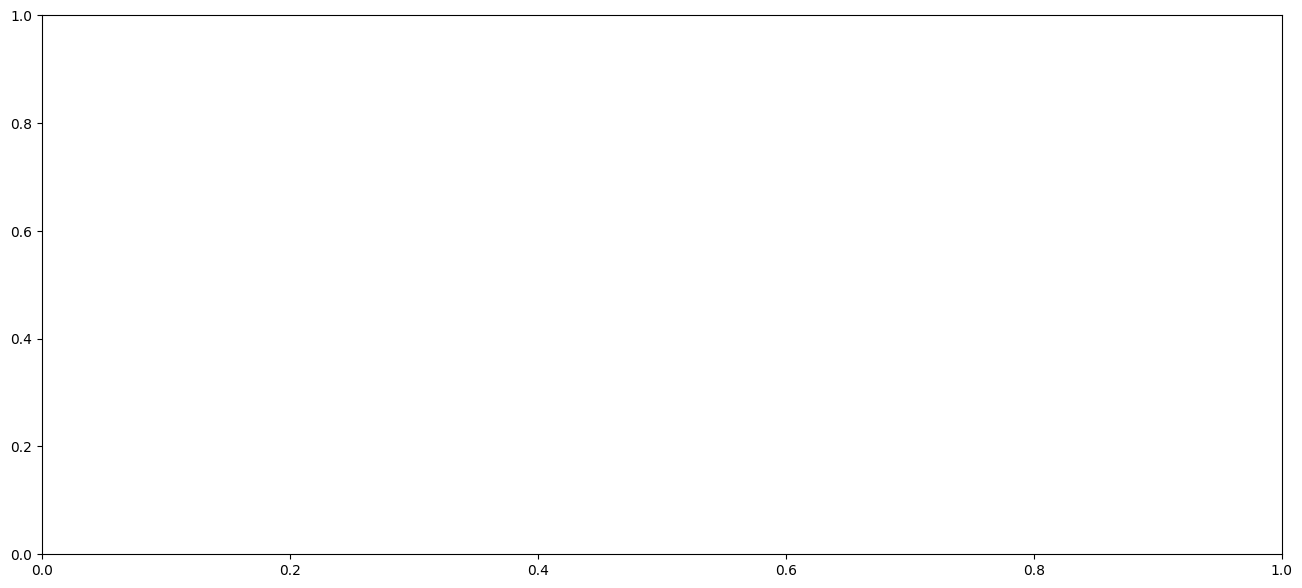

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from collections import Counter

# Hilfsfunktion zum Plotten der Entscheidungsgrenzen
def plot_decision_boundary(X, y, model, ax, title):
    """
    Plottet die Entscheidungsgrenzen eines Modells auf 2D-Daten.
    """
    # Erstelle ein Gitternetz (Meshgrid) für den Plotbereich
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Vorhersage für jeden Punkt im Gitternetz
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Zeichne die Konturen (Entscheidungsbereiche)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.jet)
    
    # Zeichne die Datenpunkte
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.jet)
    
    ax.set_title(title)
    ax.set_xlabel("Erste Hauptkomponente (PCA 1)")
    ax.set_ylabel("Zweite Hauptkomponente (PCA 2)")
    # Erstelle eine Legende, die alle 10 Klassen anzeigt
    legend1 = ax.legend(*scatter.legend_elements(), title="Klassen")
    ax.add_artist(legend1)



print("Klassenverteilung vor dem Resampling:", sorted(Counter(y_train[stratify_column]).items()))

# 2. Dimensionsreduktion mit PCA auf 2 Komponenten
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# 3. Definition des Modells
# Wir verwenden ein einfaches Modell als Proxy
model2 = LogisticRegression(solver='liblinear', multi_class='ovr')

# Erstelle die Plots (1 Zeile, 2 Spalten)
fig, axes = plt.subplots(1, 1, figsize=(16, 7))

# 4. Visualisierung VOR dem Resampling
model2.fit(X_pca, y_train[stratify_column])  # Nur eine Spalte für y_train
plot_decision_boundary(X_pca, y_train[stratify_column], model2, axes[0], "Entscheidungsgrenzen VOR Resampling")






Klassenverteilung nach dem Resampling (SMOTE): [(0, 200000), (1, 200000), (2, 200000), (3, 200000), (4, 200000), (5, 200000), (6, 200000), (7, 200000), (8, 200000), (9, 200000)]


KeyboardInterrupt: 

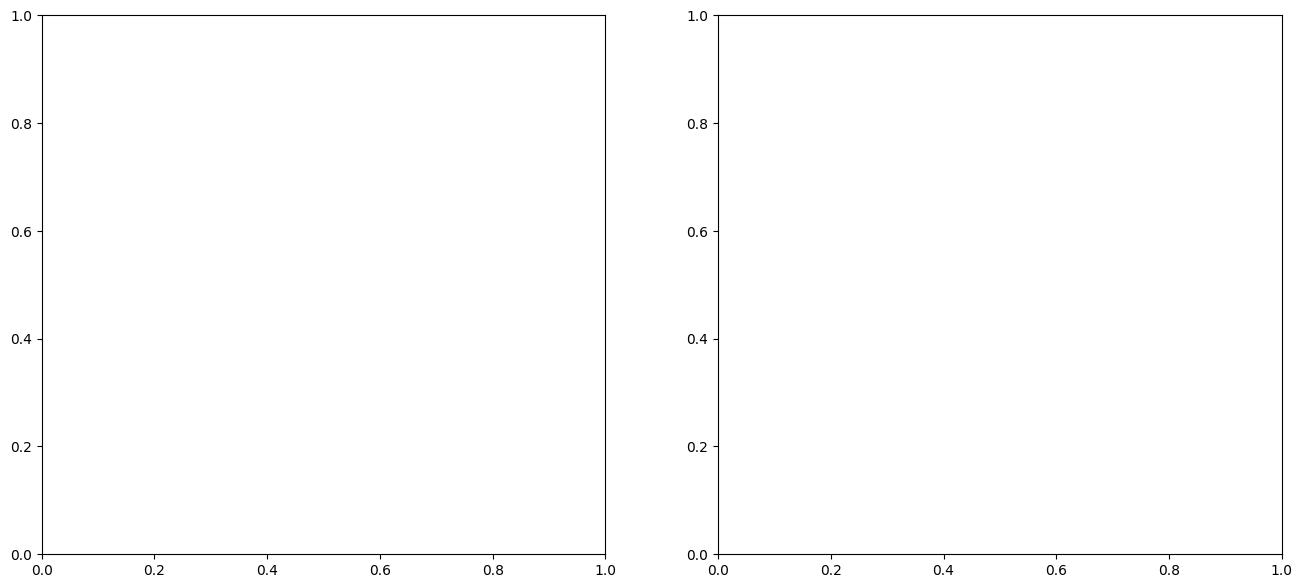

In [ ]:
"""print("\nKlassenverteilung nach dem Resampling (SMOTE):", sorted(Counter(y_train_resampled).items()))

# PCA muss auf die resampelten Daten neu angewendet werden
X_resampled_pca = pca.fit_transform(X_train_resampled)
# Erstelle die Plots (1 Zeile, 2 Spalten)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# 6. Visualisierung NACH dem Resampling
model2.fit(X_resampled_pca, y_train_resampled)
plot_decision_boundary(X_resampled_pca, y_train_resampled, model2, axes[1], "Entscheidungsgrenzen NACH Resampling (SMOTE)")

plt.tight_layout()
plt.show()"""

# Speichere die Trainings- und Test-daten ab

In [ ]:
y_train_resampled.to_csv(f"y_train_resampled_{stratify_column}_v8.csv", index=False, sep='\t', encoding='utf-8')
print("BERT Feature Converter Funktion erstellt!")
test_data = process_large_dataset(X_test, batch_size=5000, output_file="../data/test/bert_test_sequences_no_sep_v8.csv")
train_data = process_large_dataset(X_train_resampled, batch_size=5000, output_file="../data/train/bert_train_sequences_v8.csv") 

print("BERT Feature Converter bereit für Verwendung!")

BERT Feature Converter Funktion erstellt!
📊 CSV: 473085/473085
✅ 473085 Sequenzen in CSV '../data/test/bert_test_sequences_no_sep_v8.csv' gespeichert
📊 CSV: 2000000/2000000
✅ 2000000 Sequenzen in CSV '../data/train/bert_train_sequences_v8.csv' gespeichert
BERT Feature Converter bereit für Verwendung!


In [ ]:
y_test.to_csv(f"../data/test/y_test_{stratify_column}_v8.csv", index=False, sep='\t', encoding='utf-8')  # Speichern der y_test in einer Tabelle
y_train.to_csv(f"../data/train/y_train_{stratify_column}_v8.csv", index=False, sep='\t', encoding='utf-8')  # Speichern der y_train in einer Tabelle